# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to understand the Women's Clothing E-Commerce Reviews dataset before building machine learning models.

In this notebook, we will:

- Load the dataset
- Explore the dataset structure
- Identify missing values
- Analyze data distributions
- Create sentiment labels
- Save the processed dataset for the next stage

In [ ]:
# Install required libraries

!pip install pandas numpy matplotlib seaborn nltk

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
     ---------------------------------------- 0.0/41.6 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.6 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.6 kB 162.5 kB/s eta 0:00:01
     -------------------------------------  41.0/41.6 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 41.6/41.6 kB 182.2 kB/s eta 0:00:00
     ---------------------------------------- 0.0/57.3 kB ? eta -:--:--
     ------- -------------------------------- 10.2/57.3 kB ? eta -:--:--
     -------------------- ----------------- 30.7/57.3 kB 640.0 kB/s eta 0:00:01
     -------------------- ----------------- 30.7/57.3 kB 640.0 kB/s eta 0:00:01
     -------------------- ----------------- 30.7/57.3 kB 640.0 kB/s eta 0:00:01
     -------------------- ----------------- 30.7/57.3 kB 640.0 kB/s eta 0:00:01
     ------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Required Libraries

We import the libraries required for data manipulation and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

## Load Dataset

Read the dataset into a pandas DataFrame.

In [ ]:
df = pd.read_csv("../data/raw/Womens Clothing E-Commerce Reviews.csv")
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## Dataset Information

Let's inspect the dataset structure, data types, and missing values.

In [ ]:
df.shape

(23486, 11)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Unnamed: 0               23486 non-null  int64
 1   Clothing ID              23486 non-null  int64
 2   Age                      23486 non-null  int64
 3   Title                    19676 non-null  str  
 4   Review Text              22641 non-null  str  
 5   Rating                   23486 non-null  int64
 6   Recommended IND          23486 non-null  int64
 7   Positive Feedback Count  23486 non-null  int64
 8   Division Name            23472 non-null  str  
 9   Department Name          23472 non-null  str  
 10  Class Name               23472 non-null  str  
dtypes: int64(6), str(5)
memory usage: 2.0 MB


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

Title              3810
Review Text         845
Department Name      14
Class Name           14
Division Name        14
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()
df.drop(columns=["Unnamed: 0"], inplace=True)

In [ ]:
df.describe()

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


In [ ]:
df.describe(include="object")

C:\Users\hp\AppData\Local\Temp\ipykernel_18392\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Title,Review Text,Division Name,Department Name,Class Name
count,19676,22641,23472,23472,23472
unique,13993,22634,3,6,20
top,Love it!,Perfect fit and i've gotten so many compliment...,General,Tops,Dresses
freq,136,3,13850,10468,6319


In [ ]:
df.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')

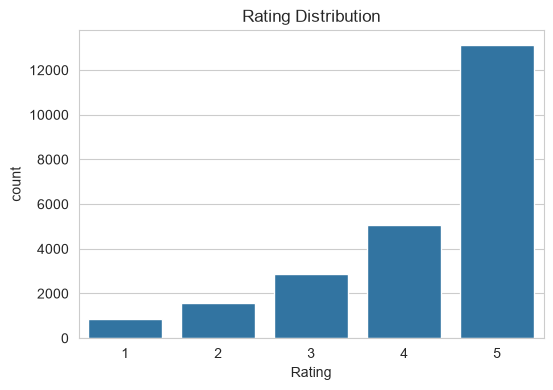

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Rating Distribution")
plt.show()

In [ ]:
df["Review Length"] = df["Review Text"].fillna("").apply(len)

In [ ]:
df["Review Length"].describe()

count    23486.000000
mean       297.581666
std        152.572686
min          0.000000
25%        173.000000
50%        292.000000
75%        451.000000
max        508.000000
Name: Review Length, dtype: float64

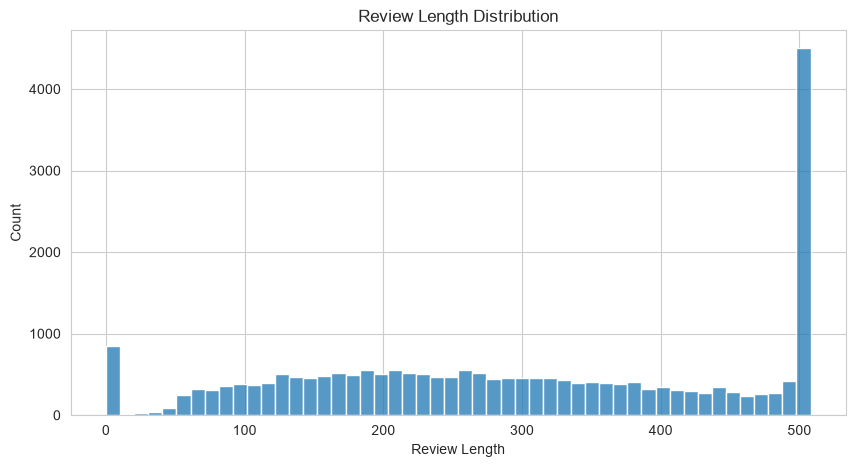

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["Review Length"], bins=50)

plt.title("Review Length Distribution")

plt.show()

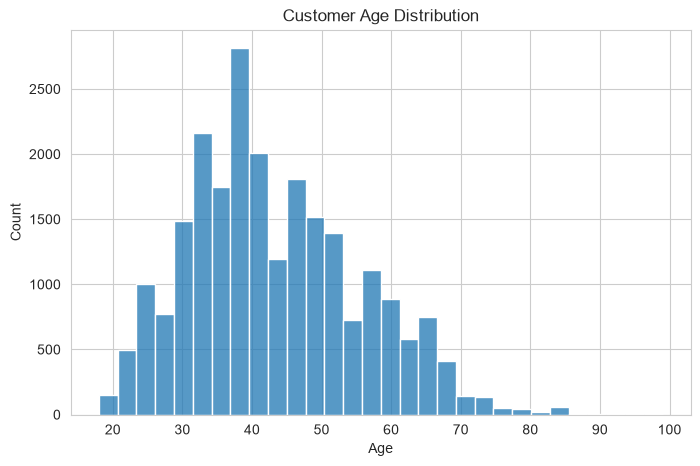

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30)

plt.title("Customer Age Distribution")

plt.show()

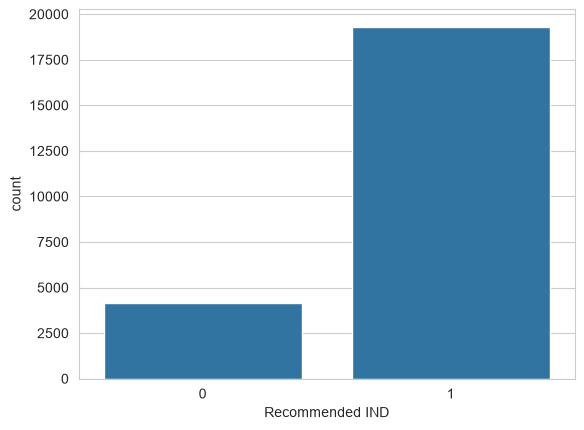

In [ ]:
sns.countplot(
    data=df,
    x="Recommended IND"
)

plt.show()

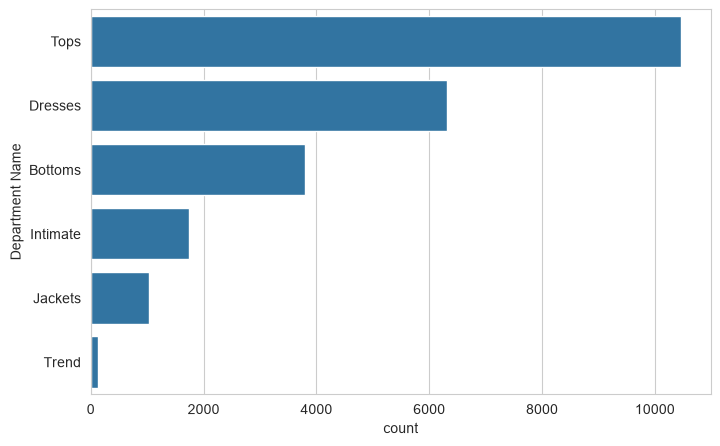

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="Department Name",
    order=df["Department Name"].value_counts().index
)

plt.show()

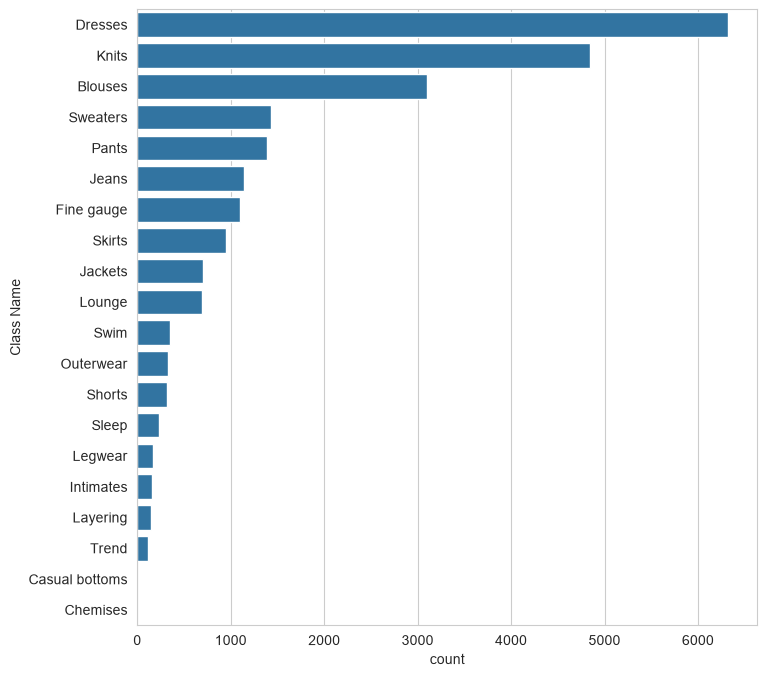

In [ ]:
plt.figure(figsize=(8,8))

sns.countplot(
    data=df,
    y="Class Name",
    order=df["Class Name"].value_counts().index
)

plt.show()

In [ ]:
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

In [ ]:
df["Sentiment"] = df["Rating"].apply(sentiment_label)
df[["Rating", "Sentiment"]].head()

,Rating,Sentiment
0,4,Positive
1,5,Positive
2,3,Neutral
3,5,Positive
4,5,Positive


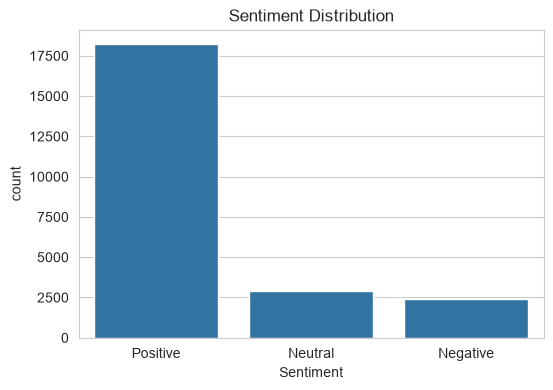

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

In [ ]:
df.to_csv("../data/processed/cleaned_reviews.csv", index=False)

In [ ]:
print("Hello")

Hello
